# 01 Cleaning: Inside Airbnb London
- **Owner:** Varuna
- **Purpose:** Audit data quality, fix or remove problem values, and produce one cleaned dataset that every team member uses.
- **Input:** `data/listings.csv.gz` (Inside Airbnb London, snapshot 19 June 2026, 92,638 rows × 90 columns)
- **Output:** `data/listings_clean.csv` (92,635 rows × 80 columns, not committed to GitHub), a decision table, a column inventory saved to `docs/column_inventory.csv`, and 4 figures saved to `figures/`
- **How to run:** Download `listings.csv.gz` for London (19 June 2026) from https://insideairbnb.com/get-the-data, place it in the `data` folder at the repo root, open this notebook from `notebooks/`, then run Kernel > Restart Kernel and Run All Cells.

## Dataset overview
- **Source:** Inside Airbnb, London, snapshot 19 June 2026 (insideairbnb.com/get-the-data), public data under CC BY 4.0.
- **Size:** 92,638 listings × 90 columns.
- **Features:** host details, location (neighbourhood, latitude, longitude), property (room type, bedrooms, bathrooms, amenities), price and booking rules, availability, and reviews (overall rating plus six sub-scores).
- **Project question:** which listing and host features predict a top rating (4.8 or higher), so hosts know what to improve first.
- **Why this dataset:** it is large, current, and combines numeric, categorical, text, and geographic data, which supports both EDA and a classification model. The overall rating is guest-given, so the target is observed, not estimated.
- **Complexity:** 14 columns are completely empty in this snapshot, price is stored as text and missing for about a third of listings, missing values also appear as text placeholders, and a quarter of listings have no rating yet.
- **Units:** prices are in GBP (local currency). The "$" in the raw file is a formatting artifact of the source export.

## Step 1: Load the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("../data/listings.csv.gz")
print(df.shape)

(92638, 90)


## Step 1b: First look
First and last rows, column types, and summary statistics before any changes.

In [2]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.2f}".format)
display(df.head(3))
display(df.tail(3))
df.info()
display(df.describe().T)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,11551,https://www.airbnb.com/rooms/11551,20260619061251,2026-06-25,city scrape,Artistic London Pied-à-Terre,Live like a local in this quintessential Londo...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,43039,https://www.airbnb.com/users/show/43039,"1,462,507,475,108,972,800.00",https://www.airbnb.com/users/profile/146250747...,Adriano,NaN,16.00,8.00,15.00,5.00,"London, United Kingdom","Hello, I'm a friendly Italian man with a posit...",NaN,NaN,NaN,t,NaN,https://a0.muscache.com/im/pictures/user/User/...,NaN,1.00,NaN,NaN,t,t,NaN,Lambeth,NaN,51.46,-0.12,Entire rental unit,Entire home/apt,5,1.00,1 bath,1.00,3.00,"[""Carbon monoxide alarm"", ""Portable air condit...",$234.50,2026-07-01,2026-07-03,469.00,234.50,"{""quote"": {""taxes"": null, ""currency"": ""GBP"", ""...",1.00,"1,125.00",1.00,5.00,1.00,"1,125.00",2.00,143.50,NaN,t,9,25,55,330,2026-06-25,196,6,1,155,3,55,"12,898.00",2010-03-21,2026-06-05,4.55,4.60,4.57,4.77,4.84,4.54,4.49,NaN,NaN,1,1,0,0,0.99
1,13913,https://www.airbnb.com/rooms/13913,20260619061251,2026-06-25,city scrape,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,54730,https://www.airbnb.com/users/show/54730,"1,462,507,796,255,381,760.00",https://www.airbnb.com/users/profile/146250779...,Alina,NaN,16.00,7.00,15.00,5.00,"London, United Kingdom",I am a Multi-Media Visual Artist and Creative ...,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/users/54730/profile...,NaN,2.00,NaN,NaN,t,t,NaN,Islington,NaN,51.57,-0.11,Private room in rental unit,Private room,1,1.00,1 shared bath,NaN,1.00,"[""Babysitter recommendations"", ""Coffee maker: ...",$127.00,2026-06-26,2026-06-27,127.00,127.00,"{""quote"": {""taxes"": null, ""currency"": ""GBP"", ""...",1.00,29.00,1.00,1.00,29.00,29.00,1.00,29.00,NaN,t,17,46,76,351,2026-06-25,57,3,0,176,6,28,"3,556.00",2010-08-18,2026-03-31,4.86,4.80,4.80,4.82,4.88,4.79,4.79,NaN,NaN,2,1,1,0,0.30
2,15400,https://www.airbnb.com/rooms/15400,20260619061251,2026-06-26,city scrape,Bright Chelsea Apartment. Chelsea!,Lots of windows and light. St Luke's Gardens ...,NaN,https://a0.muscache.com/pictures/428392/462d26...,60302,https://www.airbnb.com/users/show/60302,"1,462,507,970,949,884,160.00",https://www.airbnb.com/users/profile/146250797...,Philippa,NaN,16.00,6.00,1

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
92635,1710906779963511330,https://www.airbnb.com/rooms/1710906779963511330,20260619061251,2026-06-29,city scrape,Elegant 4BR Apartment Near Hyde Park,Stay in the heart of Central London at this st...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,156904677,https://www.airbnb.com/users/show/156904677,"1,468,530,385,772,719,360.00",https://www.airbnb.com/users/profile/146853038...,Golden,NaN,8.00,7.00,8.00,7.00,NaN,NaN,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/pictures/user/f2260...,NaN,51.00,NaN,NaN,t,t,NaN,Westminster,NaN,51.51,-0.16,Entire rental unit,Entire home/apt,8,3.00,3 baths,4.00,4.00,"[""Air conditioning"", ""Washer"", ""Kitchen"", ""Wif...","$1,019.00",2026-07-27,2026-08-02,"6,114.00","1,019.00","{""quote"": {""taxes"": null, ""currency"": ""GBP"", ""...",6.00,365.00,6.00,7.00,365.00,365.00,6.90,365.00,NaN,t,2,32,36,215,2026-06-29,0,0,0,36,0,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48,48,0,0,NaN
92636,1710920060139021009,https://www.airbnb.com/rooms/1710920060139021009,20260619061251,2026-06-29,city scrape,Cozy Urban Studio Escape | Perfect Central London,.Welcome to your comfortable studio stay in th...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,222720392,https://www.airbnb.com/users/show/222720392,"1,469,179,753,643,116,544.00",https://www.airbnb.com/users/profile/146917975...,Colin,NaN,7.00,7.00,0.00,5.00,NaN,Airbnb host with an apartment and rooms availa...,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/pictures/user/User/...,NaN,15.00,NaN,NaN,t,t,NaN,Camden,NaN,51.53,-0.12,Entire rental unit,Entire home/apt,4,1.00,1 bath,1.00,NaN,"[""Cleaning available during stay"", ""Shampoo"", ...",$149.00,2026-07-12,2026-07-13,149.00,149.00,"{""quote"": {""taxes"": null, ""currency"": ""GBP"", ""...",1.00,364.00,1.00,3.00,364.00,364.00,2.90,364.00,NaN,t,4,11,17,248,2026-06-29,0,0,0,73,0,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,10,0,0,NaN
92637,1710933572119600327,https://www.airbnb.com/rooms/1710933572119600327,20260619061251,2026-06-29,city scrape,Single - Shared bathroom,Nestled within a magnificent early 18th-centur...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,131591665,https://www.airbnb.com/users/show/131591665,"1,462,943,126,454,239,232.00",https://www.airbnb.com/users/profile/146294312...,H,NaN,9.00,1.00,8.00,0.00,"London, United 

<class 'pandas.DataFrame'>
RangeIndex: 92638 entries, 0 to 92637
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            92638 non-null  int64  
 1   listing_url                                   92638 non-null  str    
 2   scrape_id                                     92638 non-null  int64  
 3   last_scraped                                  92638 non-null  str    
 4   source                                        92638 non-null  str    
 5   name                                          92638 non-null  str    
 6   description                                   90549 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   92633 non-null  str    
 9   host_id                                       92638 non-null  int64  
 1

,count,mean,std,min,25%,50%,75%,max
id,"92,638.00","817,486,611,018,259,200.00","654,698,625,546,075,264.00","11,551.00","35,406,562.00","968,829,639,171,326,208.00","1,425,415,214,414,694,144.00","1,710,933,572,119,600,384.00"
scrape_id,"92,638.00","20,260,619,061,251.00",0.00,"20,260,619,061,251.00","20,260,619,061,251.00","20,260,619,061,251.00","20,260,619,061,251.00","20,260,619,061,251.00"
neighborhood_overview,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,"92,638.00","13,614,022,925,578,376.00","150,898,995,927,071,648.00","2,594.00","27,880,306.00","124,121,372.50","446,820,235.00","1,710,838,580,490,477,568.00"
host_profile_id,"92,562.00","1,475,941,809,439,174,400.00","38,454,015,566,094,640.00","1,462,506,313,134,451,456.00","1,463,034,538,026,982,144.00","1,466,998,371,335,809,536.00","1,470,005,057,211,590,656.00","1,710,853,459,949,883,136.00"
host_since,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hosts_time_as_user_years,"92,562.00",7.67,4.12,0.00,4.00,9.00,11.00,17.00
hosts_time_as_user_months,"92,562.00",5.45,3.55,0.00,2.00,5.00,9.00,11.00
hosts_time_as_host_years,"92,561.00",5.56,3.98,0.00,2.00,6.00,9.00,15.00
hosts_time_as_host_months,"92,561.00",5.40,3.59,0.00,2.00,5.00,9.00,11.00


## Step 2: Column audit
Each column is checked for data type, missing rate, and number of unique values. Text placeholders such as "N/A" or "-" are checked separately, because they count as present values even though they hold no information.

In [3]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_pct": (df.isna().mean() * 100).round(1),
    "n_unique": df.nunique(),
})
print(audit.sort_values("missing_pct", ascending=False).head(20))
print(df["price"].dtype, df["price"].head(3).tolist())

stand_ins = ["N/A", "NA", "null", "?", "-", "unknown", ""]
for c in df.select_dtypes(exclude="number").columns:
    n = df[c].isin(stand_ins).sum()
    if n:
        print(c, n)

                                dtype  missing_pct  n_unique
host_total_listings_count     float64       100.00         0
license                       float64       100.00         0
host_response_rate            float64       100.00         0
neighbourhood                 float64       100.00         0
host_acceptance_rate          float64       100.00         0
host_verifications            float64       100.00         0
host_since                    float64       100.00         0
host_response_time            float64       100.00         0
host_thumbnail_url            float64       100.00         0
instant_bookable              float64       100.00         0
neighborhood_overview         float64       100.00         0
neighbourhood_group_cleansed  float64       100.00         0
host_neighbourhood            float64       100.00         0
calendar_updated              float64       100.00         0
host_about                        str        46.90     23518
bathrooms               

## Step 3: Cleaning
Steps, in order: drop empty and metadata columns, convert text placeholders to missing, convert price from text to numbers, cap extreme prices in a new column, recover bathroom counts from the bathroom text, check for duplicates, and define the target `top_rated`. All listings stay in the cleaned file for EDA; the model will use rated listings only.

In [4]:
import os
import numpy as np

clean = df.copy()
notes = {}

# A. Drop columns that are 100% empty
empty_cols = audit.index[audit["missing_pct"] == 100].tolist()
clean = clean.drop(columns=empty_cols)
notes["empty_cols"] = len(empty_cols)

# B. Drop URL and scrape metadata (keep id as the join key)
meta_cols = [c for c in clean.columns if c.endswith("_url") or c in ["scrape_id", "last_scraped", "source", "calendar_last_scraped"]]
clean = clean.drop(columns=meta_cols)
notes["meta_cols"] = len(meta_cols)

# C. Text stand-ins become missing
stand_ins = ["N/A", "NA", "null", "?", "-", "unknown", ""]
for c in ["description", "host_about"]:
    if c in clean.columns:
        clean[c] = clean[c].where(~clean[c].isin(stand_ins))

# D. Price: text to number, impossible values to missing, cap extremes in a new column
clean["price"] = pd.to_numeric(clean["price"].str.replace(r"[$,]", "", regex=True), errors="coerce")
notes["price_zero"] = int((clean["price"] <= 0).sum())
clean.loc[clean["price"] <= 0, "price"] = np.nan
cap = clean["price"].quantile(0.99)
clean["price_capped"] = clean["price"].clip(upper=cap)
notes["price_cap"] = cap
notes["price_above_cap"] = int((clean["price"] > cap).sum())

# E. Bathrooms: recover missing values from bathrooms_text ("1.5 baths", "Half-bath")
notes["bath_filled"] = 0
if "bathrooms_text" in clean.columns:
    bt = clean["bathrooms_text"]
    num = pd.to_numeric(bt.str.extract(r"(\d+\.?\d*)")[0], errors="coerce")
    num = num.mask(num.isna() & bt.str.contains("half", case=False, na=False), 0.5)
    fill = clean["bathrooms"].isna() & num.notna()
    clean.loc[fill, "bathrooms"] = num[fill]
    notes["bath_filled"] = int(fill.sum())

# F. Duplicates, checked without id
dup = clean.drop(columns=["id"]).duplicated()
notes["duplicates"] = int(dup.sum())
clean = clean[~dup]

# G. Target: rating 0 treated as missing; top_rated = rating >= 4.8
notes["rating_zero"] = int((clean["review_scores_rating"] == 0).sum())
clean.loc[clean["review_scores_rating"] == 0, "review_scores_rating"] = np.nan
rated = clean["review_scores_rating"].notna()
clean["top_rated"] = (clean["review_scores_rating"] >= 4.8).astype("Int64").where(rated)
notes["rated"] = int(rated.sum())
notes["unrated"] = int((~rated).sum())
notes["top_share"] = clean.loc[rated, "top_rated"].mean()

# H. Where is price missing?
pm = clean["price"].isna()
notes["price_missing_pct"] = pm.mean() * 100
notes["price_same_as_quote"] = (pm == clean["price_quote_price_per_night"].isna()).mean() * 100
notes["avail0_missing"] = (clean.loc[pm, "availability_365"] == 0).mean() * 100
notes["avail0_present"] = (clean.loc[~pm, "availability_365"] == 0).mean() * 100

# I. Save
os.makedirs("../figures", exist_ok=True)
clean.to_csv("../data/listings_clean.csv", index=False)
print(clean.shape)
for k, v in notes.items():
    print(k, round(v, 2) if isinstance(v, float) else v)

(92635, 69)
empty_cols 14
meta_cols 9
price_zero 0
price_cap 1373.46
price_above_cap 623
bath_filled 34750
duplicates 3
rating_zero 3
rated 70708
unrated 21927
top_share 0.56
price_missing_pct 32.81
price_same_as_quote 100.0
avail0_missing 87.24
avail0_present 0.0


## Step 3b: Size columns and missing-value filling
Checks zero and extreme values in bedrooms, beds, bathrooms and minimum nights. Missing model inputs are filled with room-type medians in new columns; the original columns are kept.

In [5]:
size = ["bedrooms", "beds", "bathrooms"]
display(clean[size + ["accommodates", "minimum_nights"]].describe(percentiles=[0.5, 0.99, 0.999]).T.round(1))

# Zeros
z = clean["bedrooms"] == 0
text = (clean["name"].fillna("") + " " + clean["description"].fillna("")).str.lower()
notes["bedrooms_zero"] = int(z.sum())
notes["studio_share"] = float(text[z].str.contains("studio").mean() * 100) if z.any() else 0.0

notes["beds_zero"] = int((clean["beds"] == 0).sum())
clean.loc[clean["beds"] == 0, "beds"] = np.nan

b0 = clean["bathrooms"] == 0
notes["bath_zero"] = int(b0.sum())
notes["bath0_text_share"] = float(clean.loc[b0, "bathrooms_text"].fillna("").str.startswith("0").mean() * 100) if b0.any() else 0.0

# Extreme sizes: flag, keep values
p999 = clean[size].quantile(0.999)
ext = (clean[size] > p999).any(axis=1)
clean["size_extreme"] = ext.astype(int)
notes["size_extreme"] = int(ext.sum())
notes["p999"] = p999.round(0).to_dict()

# Minimum nights above a year: capped copy
notes["minnights_over_year"] = int((clean["minimum_nights"] > 365).sum())
clean["minimum_nights_capped"] = clean["minimum_nights"].clip(upper=365)

# Filling for model inputs: room-type median + missing flag
for c in ["price_capped", "beds", "bedrooms", "bathrooms"]:
    clean[f"{c}_missing"] = clean[c].isna().astype(int)
    med = clean.groupby("room_type")[c].transform("median")
    clean[f"{c}_imp"] = clean[c].fillna(med).fillna(clean[c].median())

clean.to_csv("../data/listings_clean.csv", index=False)
print(clean.shape)
for k in ["bedrooms_zero", "studio_share", "beds_zero", "bath_zero", "bath0_text_share",
          "size_extreme", "p999", "minnights_over_year"]:
    print(k, notes[k])

,count,mean,std,min,50%,99%,99.9%,max
bedrooms,"68,653.00",1.80,1.00,0.00,1.00,5.00,8.00,30.00
beds,"60,161.00",2.00,1.50,1.00,2.00,7.00,12.00,50.00
bathrooms,"92,509.00",1.30,0.70,0.00,1.00,3.50,6.00,30.00
accommodates,"92,635.00",3.40,2.10,1.00,3.00,10.00,16.00,16.00
minimum_nights,"92,630.00",4.60,20.90,1.00,2.00,40.00,365.00,"1,125.00"


(92635, 79)
bedrooms_zero 18
studio_share 11.11111111111111
beds_zero 0
bath_zero 725
bath0_text_share 100.0
size_extreme 122
p999 {'bedrooms': 8.0, 'beds': 12.0, 'bathrooms': 6.0}
minnights_over_year 25


## Step 3c: Maximum-nights placeholder
Replaces the placeholder value 2,147,483,647 ("no limit") with a realistic cap in a new column; the original column is kept.

In [6]:
sentinel = 2_147_483_647
night_cols = ["maximum_nights", "minimum_maximum_nights", "maximum_maximum_nights", "maximum_nights_avg_ntm"]
notes["max_nights_sentinel"] = int((clean["maximum_nights"] == sentinel).sum())
notes["max_nights_over"] = int((clean["maximum_nights"] > 1125).sum())
clean["maximum_nights_capped"] = clean["maximum_nights"].clip(upper=1125)
clean.to_csv("../data/listings_clean.csv", index=False)
print("maximum_nights at the placeholder:", notes["max_nights_sentinel"])
print("maximum_nights above 1,125:", notes["max_nights_over"])
print(clean[night_cols].eq(sentinel).sum())

maximum_nights at the placeholder: 9
maximum_nights above 1,125: 18
maximum_nights            9
minimum_maximum_nights    3
maximum_maximum_nights    9
maximum_nights_avg_ntm    3
dtype: int64


## Figure 1: Missing values by column
Shows which columns are usable and which needed a decision. Color marks the action taken.

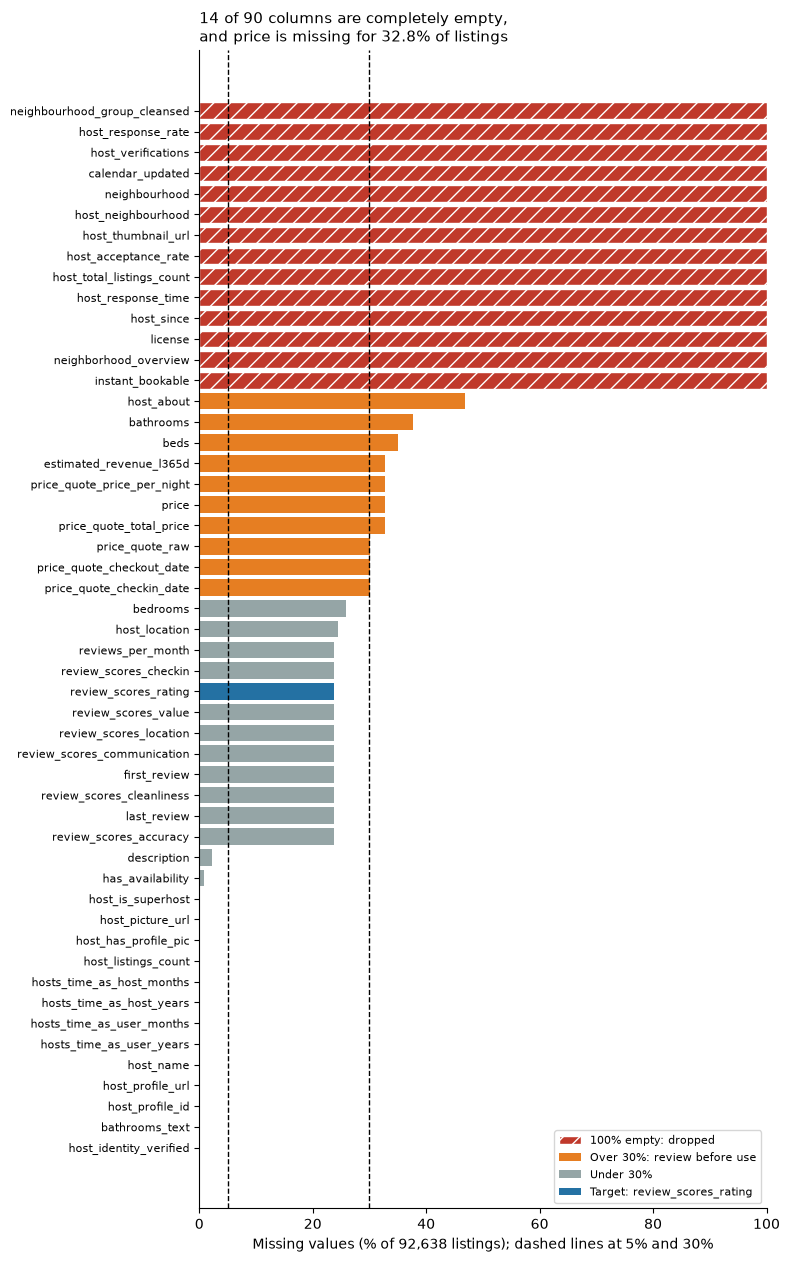

**Insight:** 14 empty columns were dropped, including host-behaviour columns (response rate, acceptance rate, response time), so those cannot be used as features. The target is missing for 23.7% of listings; these listings have no reviews, so they are excluded from the model, not imputed.

In [7]:
from matplotlib.patches import Patch
from IPython.display import Markdown, display

miss = audit.loc[audit["missing_pct"] > 0, "missing_pct"].sort_values()
colors = []
for col, v in miss.items():
    if col == "review_scores_rating":
        colors.append("#2471A3")
    elif v == 100:
        colors.append("#C0392B")
    elif v > 30:
        colors.append("#E67E22")
    else:
        colors.append("#95A5A6")

fig, ax = plt.subplots(figsize=(8, 0.22 * len(miss) + 1.5))
bars = ax.barh(miss.index, miss.values, color=colors)
for b, v in zip(bars, miss.values):
    if v == 100:
        b.set_hatch("//")
        b.set_edgecolor("white")
for x in (5, 30):
    ax.axvline(x, ls="--", lw=1, color="black")
ax.set_xlim(0, 100)
ax.set_xlabel("Missing values (% of 92,638 listings); dashed lines at 5% and 30%")
ax.tick_params(axis="y", labelsize=8)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.set_title(f"{(miss == 100).sum()} of {df.shape[1]} columns are completely empty,\n"
             f"and price is missing for {audit.loc['price', 'missing_pct']}% of listings",
             loc="left", fontsize=11)
ax.legend(handles=[Patch(facecolor="#C0392B", edgecolor="white", hatch="//", label="100% empty: dropped"),
                   Patch(facecolor="#E67E22", label="Over 30%: review before use"),
                   Patch(facecolor="#95A5A6", label="Under 30%"),
                   Patch(facecolor="#2471A3", label="Target: review_scores_rating")],
          loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("../figures/fig1_missing_values.png", dpi=500, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Insight:** {notes['empty_cols']} empty columns were dropped, including host-behaviour columns "
    f"(response rate, acceptance rate, response time), so those cannot be used as features. "
    f"The target is missing for {audit.loc['review_scores_rating', 'missing_pct']}% of listings; "
    f"these listings have no reviews, so they are excluded from the model, not imputed."))

## Figure 2: Price before and after cleaning
Shows the effect of capping extreme prices at the 99th percentile.

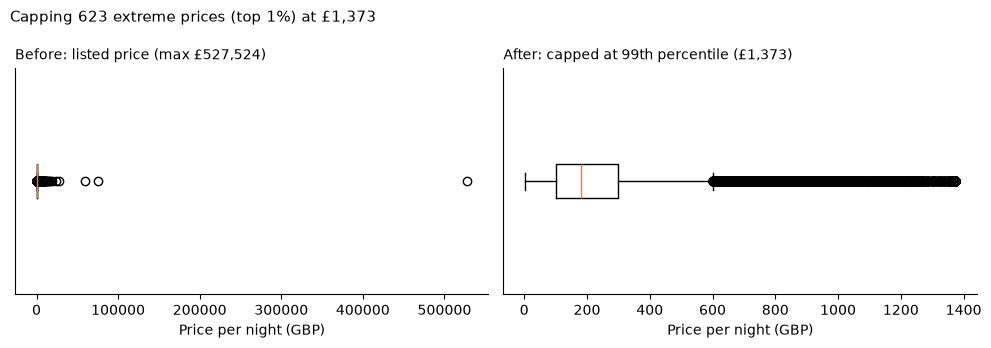

**Insight:** the maximum price (£527,524 per night) is almost certainly an entry error. The other 622 capped listings may be genuine high-end stays, so they are capped, not deleted. Capping keeps every listing with a valid rating while limiting extreme values' effect on charts and models. The original `price` column is kept unchanged.

In [8]:
p = clean["price"].dropna()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].boxplot(p.values, orientation="horizontal")
axes[0].set_title(f"Before: listed price (max £{p.max():,.0f})", loc="left", fontsize=10)
axes[1].boxplot(p.clip(upper=cap).values, orientation="horizontal")
axes[1].set_title(f"After: capped at 99th percentile (£{cap:,.0f})", loc="left", fontsize=10)
for ax in axes:
    ax.set_xlabel("Price per night (GBP)")
    ax.set_yticks([])
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
fig.suptitle(f"Capping {notes['price_above_cap']:,} extreme prices (top 1%) at £{cap:,.0f}",
             x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.savefig("../figures/fig2_price_before_after.png", dpi=500, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Insight:** the maximum price (£{p.max():,.0f} per night) is almost certainly an entry error. "
    f"The other {notes['price_above_cap'] - 1:,} capped listings may be genuine high-end stays, so they are capped, not deleted. "
    f"Capping keeps every listing with a valid rating while limiting extreme values' effect on charts and models. "
    f"The original `price` column is kept unchanged."))

## Step 4: Decision table

In [9]:
n = notes
p = n["p999"]
low_n = int((clean["price"] < 10).sum())
low_min = clean["price"].min()
z_n = n["bedrooms_zero"]
z_studio = round(z_n * n["studio_share"] / 100)
beds_dec = "Checked: none found" if n["beds_zero"] == 0 else f"{n['beds_zero']:,} rows treated as missing"

display(Markdown(f"""
| Column / issue | Decision | Because |
|---|---|---|
| {n['empty_cols']} columns 100% empty (e.g. `host_since`, `license`) | Dropped | No values in this snapshot |
| {n['meta_cols']} URL and scrape metadata columns | Dropped; `id` kept | No analytical value; `id` joins to the calendar file |
| `price` stored as text ("\\$234.50") | Converted to number, unit GBP | The source defines price in local currency; the "\\$" sign is an export artifact |
| `price` of 0 or less ({n['price_zero']} rows) | Treated as missing | A nightly price cannot be zero or negative |
| `price` below £10 ({low_n:,} rows; lowest £{low_min:.2f}) | Kept as listed; noted as possible entry errors | Too few rows to change results |
| `price` missing ({n['price_missing_pct']:.1f}%) | Kept as missing in `price`; filled in `price_capped_imp` | Same rows as missing `price_quote_price_per_night` ({n['price_same_as_quote']:.0f}% match); {n['avail0_missing']:.0f}% of these have 0 days available vs {n['avail0_present']:.0f}% of priced listings |
| {n['price_above_cap']:,} prices above the 99th percentile (£{n['price_cap']:,.0f}) | Capped in new column `price_capped`; original kept | The maximum is an entry error; the rest may be genuine high-end stays, so they are capped, not deleted |
| `bathrooms` {audit.loc['bathrooms', 'missing_pct']}% missing | {n['bath_filled']:,} values recovered from `bathrooms_text` | Same information stored as text ("1.5 baths") |
| `bedrooms` = 0 ({z_n:,} rows) | Kept as listed | Too few to affect results ({z_n / len(clean):.2%} of listings); only {z_studio} mention "studio", so some may be entry errors |
| `beds` = 0 | {beds_dec} | A listing that takes guests needs at least one bed |
| `bathrooms` = 0 ({n['bath_zero']:,} rows) | Kept as listed | {n['bath0_text_share']:.0f}% of these state 0 baths in the bathroom text |
| {n['size_extreme']:,} listings above the 99.9th percentile (bedrooms > {p['bedrooms']:.0f}, beds > {p['beds']:.0f}, bathrooms > {p['bathrooms']:.0f}) | Flagged in `size_extreme`; values kept | Large properties exist; the flag lets the model test whether they behave differently |
| `minimum_nights` above 365 ({n['minnights_over_year']:,} rows) | Capped at 365 in `minimum_nights_capped` | A minimum stay over a year is outside short-term letting |
| `maximum_nights` = 2,147,483,647 ({n['max_nights_sentinel']:,} rows) | Capped at 1,125 in `maximum_nights_capped` ({n['max_nights_over']:,} rows above 1,125) | 2,147,483,647 is the largest value a 32-bit integer can store, most likely a placeholder for "no limit", not a real stay length; 1,125 is the 75th percentile |
| Missing `price_capped`, `beds`, `bedrooms`, `bathrooms` | Filled with the room-type median in new `_imp` columns, plus `_missing` flags; originals kept | Values are skewed, so the median is not pulled by outliers; room type sets typical size; missingness is linked to the target (Figure 3). Medians will be recomputed on the training split at modeling time |
| Text placeholders in `description`, `host_about` | Treated as missing | They look filled in but hold no information |
| Duplicate rows, checked without `id` | {n['duplicates']} found{"; dropped" if n['duplicates'] else ""} | A unique ID hides duplicates, so it is excluded from the check |
| `review_scores_rating` = 0 ({n['rating_zero']} rows) | Treated as missing | Not a valid star rating |
| {n['unrated']:,} listings with no rating | Kept for EDA; excluded from the model; never filled | A missing target cannot be filled without inventing answers |
| Review sub-scores, `host_is_superhost` | Kept for EDA; excluded from model features | Sub-scores come from the same stay as the target; Superhost status is partly decided by rating |
| New target `top_rated` | 1 if rating is 4.8 or higher, else 0 | {n['top_share']:.0%} of {n['rated']:,} rated listings are top rated |
"""))


| Column / issue | Decision | Because |
|---|---|---|
| 14 columns 100% empty (e.g. `host_since`, `license`) | Dropped | No values in this snapshot |
| 9 URL and scrape metadata columns | Dropped; `id` kept | No analytical value; `id` joins to the calendar file |
| `price` stored as text ("\$234.50") | Converted to number, unit GBP | The source defines price in local currency; the "\$" sign is an export artifact |
| `price` of 0 or less (0 rows) | Treated as missing | A nightly price cannot be zero or negative |
| `price` below £10 (25 rows; lowest £2.23) | Kept as listed; noted as possible entry errors | Too few rows to change results |
| `price` missing (32.8%) | Kept as missing in `price`; filled in `price_capped_imp` | Same rows as missing `price_quote_price_per_night` (100% match); 87% of these have 0 days available vs 0% of priced listings |
| 623 prices above the 99th percentile (£1,373) | Capped in new column `price_capped`; original kept | The maximum is an entry error; the rest may be genuine high-end stays, so they are capped, not deleted |
| `bathrooms` 37.6% missing | 34,750 values recovered from `bathrooms_text` | Same information stored as text ("1.5 baths") |
| `bedrooms` = 0 (18 rows) | Kept as listed | Too few to affect results (0.02% of listings); only 2 mention "studio", so some may be entry errors |
| `beds` = 0 | Checked: none found | A listing that takes guests needs at least one bed |
| `bathrooms` = 0 (725 rows) | Kept as listed | 100% of these state 0 baths in the bathroom text |
| 122 listings above the 99.9th percentile (bedrooms > 8, beds > 12, bathrooms > 6) | Flagged in `size_extreme`; values kept | Large properties exist; the flag lets the model test whether they behave differently |
| `minimum_nights` above 365 (25 rows) | Capped at 365 in `minimum_nights_capped` | A minimum stay over a year is outside short-term letting |
| `maximum_nights` = 2,147,483,647 (9 rows) | Capped at 1,125 in `maximum_nights_capped` (18 rows above 1,125) | 2,147,483,647 is the largest value a 32-bit integer can store, most likely a placeholder for "no limit", not a real stay length; 1,125 is the 75th percentile |
| Missing `price_capped`, `beds`, `bedrooms`, `bathrooms` | Filled with the room-type median in new `_imp` columns, plus `_missing` flags; originals kept | Values are skewed, so the median is not pulled by outliers; room type sets typical size; missingness is linked to the target (Figure 3). Medians will be recomputed on the training split at modeling time |
| Text placeholders in `description`, `host_about` | Treated as missing | They look filled in but hold no information |
| Duplicate rows, checked without `id` | 3 found; dropped | A unique ID hides duplicates, so it is excluded from the check |
| `review_scores_rating` = 0 (3 rows) | Treated as missing | Not a valid star rating |
| 21,927 listings with no rating | Kept for EDA; excluded from the model; never filled | A missing target cannot be filled without inventing answers |
| Review sub-scores, `host_is_superhost` | Kept for EDA; excluded from model features | Sub-scores come from the same stay as the target; Superhost status is partly decided by rating |
| New target `top_rated` | 1 if rating is 4.8 or higher, else 0 | 56% of 70,708 rated listings are top rated |


## Column inventory: type, unit, missing rate, verdict
Every column from the raw file plus every column created during cleaning. Also saved to `docs/column_inventory.csv` for the report appendix.

In [10]:
def unit_of(c, s):
    n_ = c.lower()
    if s.isna().all():
        return "n/a (empty)"
    if n_.endswith("_date") or n_.endswith("_review") or n_ in ("last_scraped", "calendar_last_scraped"):
        return "date"
    if n_ == "id" or n_.endswith("_id"):
        return "identifier"
    if n_.endswith("_missing") or n_ in ("top_rated", "size_extreme"):
        return "1/0 flag"
    if "price" in n_ or "revenue" in n_:
        return "GBP" if pd.api.types.is_numeric_dtype(s) else "GBP (stored as text)"
    if n_ in ("latitude", "longitude"):
        return "degrees"
    if n_.startswith("availability"):
        return "days"
    if "nights" in n_:
        return "nights"
    if "occupancy" in n_:
        return "nights (estimated)"
    if n_.startswith("review_scores"):
        return "rating (0 to 5)"
    if n_ == "reviews_per_month":
        return "reviews per month"
    if "number_of_reviews" in n_:
        return "count of reviews"
    if "listings_count" in n_:
        return "count of listings"
    if n_.endswith("_months"):
        return "months"
    if n_.endswith("_years"):
        return "years"
    if n_ == "accommodates":
        return "count of guests"
    if n_.startswith(("bedrooms", "beds", "bathrooms")) and pd.api.types.is_numeric_dtype(s):
        return "count"
    if s.dropna().astype(str).isin(["t", "f"]).all():
        return "t/f flag"
    if n_.endswith("_url"):
        return "URL"
    return "number" if pd.api.types.is_numeric_dtype(s) else "text / category"

created = [c for c in clean.columns if c not in df.columns]
leak = [c for c in df.columns if c.startswith("review_scores_") and c != "review_scores_rating"] + ["host_is_superhost"]

def verdict_of(c, s, unit):
    if c in empty_cols:
        return "Dropped: 100% empty"
    if c in meta_cols:
        return "Dropped: URL or scrape metadata"
    if c == "id":
        return "Kept: key (joins to calendar)"
    if c == "review_scores_rating":
        return "Kept: source of target"
    if c == "top_rated":
        return "Created: target"
    if c in leak:
        return "Kept for EDA only: leakage"
    if c == "price":
        return "Converted to number (GBP); see price_capped"
    if c in created:
        return "Created in cleaning"
    if unit == "identifier":
        return "Kept: identifier, not a feature"
    if unit == "date":
        return "Kept for EDA: date"
    if pd.api.types.is_numeric_dtype(s):
        return "Kept: candidate feature"
    if s.nunique() <= 300:
        return "Kept: categorical feature candidate"
    return "Kept for EDA: free text"

rows = []
for c in list(df.columns) + created:
    s = clean[c] if c in clean.columns else df[c]
    u = unit_of(c, s)
    rows.append({"column": c, "type": str(s.dtype), "unit": u,
                 "missing_%": round(s.isna().mean() * 100, 1),
                 "verdict": verdict_of(c, s, u)})
inventory = pd.DataFrame(rows).set_index("column")
os.makedirs("../docs", exist_ok=True)
inventory.to_csv("../docs/column_inventory.csv")
pd.set_option("display.max_rows", 200)
display(inventory)

,type,unit,missing_%,verdict
column,,,,
id,int64,identifier,0.00,Kept: key (joins to calendar)
listing_url,str,URL,0.00,Dropped: URL or scrape metadata
scrape_id,int64,identifier,0.00,Dropped: URL or scrape metadata
last_scraped,str,date,0.00,Dropped: URL or scrape metadata
source,str,text / category,0.00,Dropped: URL or scrape metadata
name,str,text / category,0.00,Kept for EDA: free text
description,str,text / category,2.30,Kept for EDA: free text
neighborhood_overview,float64,n/a (empty),100.00,Dropped: 100% empty
picture_url,str,URL,0.00,Dropped: URL or scrape metadata


## Step 5: Challenges so far

- **Host-behaviour columns are empty.** Response rate, acceptance rate, and response time have no values in this snapshot, so fewer host features are available for the model.
- **Price is missing only for listings that cannot be booked.** 32.8% of listings have no price; all of them also lack a price quote, and 87% have 0 days available (vs 0% of priced listings).
- **The target is missing for unreviewed listings.** 21,927 listings have no rating, so the model only describes listings that already have reviews.
- **Ratings are bunched near the top.** The median rating is 4.83 and 56% of rated listings reach 4.8, so small rating differences decide the class.
- **Leakage risk.** Review sub-scores and Superhost status are tied to the rating, so they are excluded from model features.

## Figure 3: Top-rated share when values are missing vs present
Checks whether missing values are random or linked to the target, which decides how missing values are handled in the model.

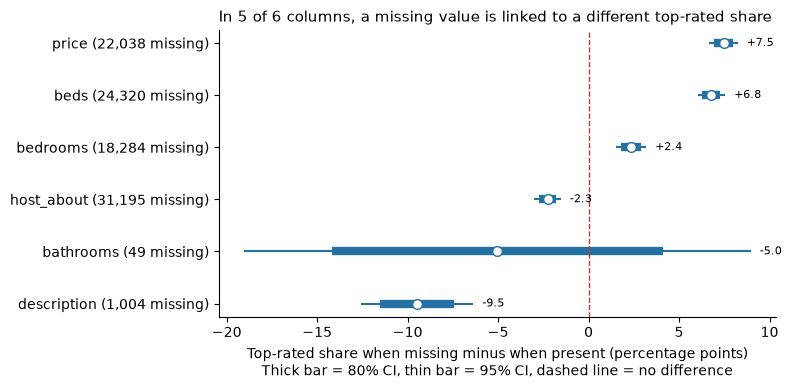

**Insight:** Listings missing `bedrooms`, `beds`, `price` are more often top rated; listings missing `description`, `host_about` are less often top rated. Intervals crossing the dashed line (`bathrooms`) may be noise. Where missingness carries signal, a 'value missing' flag can enter the model instead of dropping rows.

In [11]:
r = clean[clean["top_rated"].notna()]
rows = []
for c in ["price", "beds", "bedrooms", "bathrooms", "description", "host_about"]:
    m = r[c].isna()
    n1, n0 = int(m.sum()), int((~m).sum())
    if n1 == 0:
        continue
    p1, p0 = r.loc[m, "top_rated"].mean(), r.loc[~m, "top_rated"].mean()
    se = np.sqrt(p1 * (1 - p1) / n1 + p0 * (1 - p0) / n0)
    rows.append({"label": f"{c} ({n1:,} missing)", "diff": (p1 - p0) * 100,
                 "ci95": 1.96 * se * 100, "ci80": 1.2816 * se * 100})
d = pd.DataFrame(rows).sort_values("diff").reset_index(drop=True)
sig = d[d["diff"].abs() > d["ci95"]]
ns = d[d["diff"].abs() <= d["ci95"]]

fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(d))
ax.hlines(y, d["diff"] - d["ci95"], d["diff"] + d["ci95"], color="#2471A3", lw=1.5)
ax.hlines(y, d["diff"] - d["ci80"], d["diff"] + d["ci80"], color="#2471A3", lw=6)
ax.plot(d["diff"], y, "o", color="white", mec="#2471A3", ms=7)
ax.axvline(0, color="#C0392B", ls="--", lw=1)
for yi, (dv, c95) in enumerate(zip(d["diff"], d["ci95"])):
    ax.text(dv + c95 + 0.5, yi, f"{dv:+.1f}", va="center", fontsize=8)
ax.set_yticks(y)
ax.set_yticklabels(d["label"])
ax.set_xlabel("Top-rated share when missing minus when present (percentage points)\n"
              "Thick bar = 80% CI, thin bar = 95% CI, dashed line = no difference")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.set_title(f"In {len(sig)} of {len(d)} columns, a missing value is linked to a different top-rated share",
             loc="left", fontsize=11)
plt.tight_layout()
plt.savefig("../figures/fig3_missing_vs_target.png", dpi=500, bbox_inches="tight")
plt.show()

names = lambda s: ", ".join(f"`{x.split(' (')[0]}`" for x in s["label"])
up, down = sig[sig["diff"] > 0], sig[sig["diff"] < 0]
parts = []
if len(up):
    parts.append(f"listings missing {names(up)} are more often top rated")
if len(down):
    parts.append(f"listings missing {names(down)} are less often top rated")
text = ("; ".join(parts) + ". ") if parts else "No column shows a reliable difference. "
if len(ns):
    text += f"Intervals crossing the dashed line ({names(ns)}) may be noise. "
text += "Where missingness carries signal, a 'value missing' flag can enter the model instead of dropping rows."
display(Markdown(f"**Insight:** {text[0].upper() + text[1:]}"))

## Figure 4: Rated vs unrated listings
The model can only learn from rated listings. This compares them with the unrated listings it leaves out.

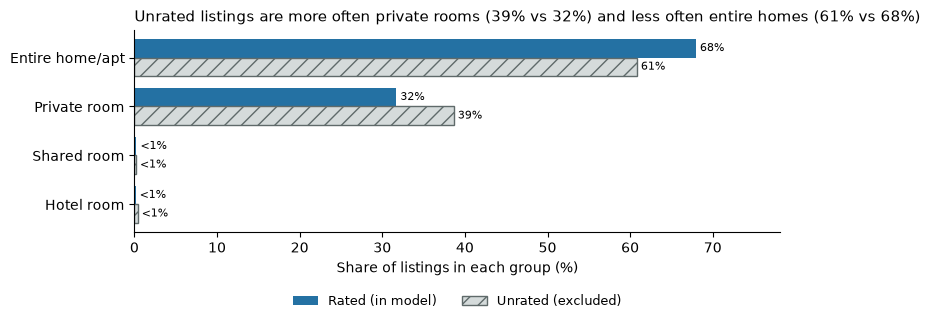

**Insight:** unrated listings differ from rated ones (median availability 171 vs 118 days; median price £189 vs £178). Model results apply to reviewed listings only and should not be generalised to new listings.

In [12]:
grp = clean["top_rated"].notna().map({True: "Rated (in model)", False: "Unrated (excluded)"})
share = (pd.crosstab(clean["room_type"], grp, normalize="columns") * 100).sort_values("Rated (in model)")
fig, ax = plt.subplots(figsize=(8, 3.5))
y, h = np.arange(len(share)), 0.38
b1 = ax.barh(y + h / 2, share["Rated (in model)"], h, color="#2471A3", label="Rated (in model)")
b2 = ax.barh(y - h / 2, share["Unrated (excluded)"], h, color="#D5DBDB", hatch="//",
             edgecolor="#5F6A6A", label="Unrated (excluded)")
for bars in (b1, b2):
    ax.bar_label(bars, labels=[f"{v:.0f}%" if v >= 1 else "<1%" for v in bars.datavalues],
                 padding=3, fontsize=8)
ax.set_yticks(y)
ax.set_yticklabels(share.index)
ax.set_xlim(0, share.values.max() * 1.15)
ax.set_xlabel("Share of listings in each group (%)")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=2, frameon=False, fontsize=9)
pr, pu = share.loc["Private room"]
er, eu = share.loc["Entire home/apt"]
ax.set_title(f"Unrated listings are {'more' if pu > pr else 'less'} often private rooms ({pu:.0f}% vs {pr:.0f}%) "
             f"and {'more' if eu > er else 'less'} often entire homes ({eu:.0f}% vs {er:.0f}%)",
             loc="left", fontsize=11)
plt.tight_layout()
plt.savefig("../figures/fig4_rated_vs_unrated.png", dpi=500, bbox_inches="tight")
plt.show()
med = clean.groupby(grp)[["availability_365", "price"]].median()
display(Markdown(
    f"**Insight:** unrated listings differ from rated ones (median availability "
    f"{med.loc['Unrated (excluded)', 'availability_365']:.0f} vs {med.loc['Rated (in model)', 'availability_365']:.0f} days; "
    f"median price £{med.loc['Unrated (excluded)', 'price']:,.0f} vs £{med.loc['Rated (in model)', 'price']:,.0f}). "
    f"Model results apply to reviewed listings only and should not be generalised to new listings."))

## Step 6: Check after cleaning
Confirms that the cleaning did what the decision table says and broke nothing.

In [13]:
num_cols = ["price", "price_capped", "bedrooms", "beds", "bathrooms", "minimum_nights_capped", "review_scores_rating"]
display(clean[num_cols].describe().T.round(2))
checks = {
    "price is numeric": pd.api.types.is_numeric_dtype(clean["price"]),
    "no price at or below 0": bool((clean["price"].dropna() > 0).all()),
    "ratings between 1 and 5": bool(clean["review_scores_rating"].dropna().between(1, 5).all()),
    "no beds equal to 0": bool((clean["beds"].dropna() > 0).all()),
    "no duplicate rows (without id)": not clean.drop(columns=["id"]).duplicated().any(),
    "top_rated is only 0, 1 or missing": set(clean["top_rated"].dropna().unique()) <= {0, 1},
    "minimum nights capped at 365": bool((clean["minimum_nights_capped"].dropna() <= 365).all()),
}
display(pd.Series(checks, name="passed").to_frame())

,count,mean,std,min,25%,50%,75%,max
price,"62,238.00",271.48,"2,190.63",2.23,100.00,180.00,300.10,"527,524.00"
price_capped,"62,238.00",244.37,225.07,2.23,100.00,180.00,300.10,"1,373.46"
bedrooms,"68,653.00",1.77,1.04,0.00,1.00,1.00,2.00,30.00
beds,"60,161.00",2.02,1.45,1.00,1.00,2.00,3.00,50.00
bathrooms,"92,509.00",1.33,0.69,0.00,1.00,1.00,1.50,30.00
minimum_nights_capped,"92,630.00",4.44,16.79,1.00,1.00,2.00,3.00,365.00
review_scores_rating,"70,708.00",4.69,0.48,1.00,4.60,4.83,5.00,5.00


,passed
price is numeric,True
no price at or below 0,True
ratings between 1 and 5,True
no beds equal to 0,True
no duplicate rows (without id),True
"top_rated is only 0, 1 or missing",True
minimum nights capped at 365,True
